# 05. Forecasting and model validation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahleksu/arima-workshop-ccis/blob/main/notebooks/05_forecasting_validation.ipynb)

**Module 5.** You will compare point forecasts with intervals, compute error metrics, run a rolling-origin backtest against a naive baseline, handle a structural break and outliers, and wrap the model in a small forecast pipeline.

**Why this matters for research:** a dissertation chapter on forecasting is only as strong as its evaluation. A model can fit the past very well and still forecast poorly.

In [1]:
# Setup. Runs on Google Colab and on a local install.
import importlib.util, subprocess, sys, warnings
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB and importlib.util.find_spec("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])

warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.grid": True, "grid.alpha": 0.3})
RAW = "https://raw.githubusercontent.com/ahleksu/arima-workshop-ccis/main/data/"


def _read_energy(path):
    df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    df.index.freq = "D"
    return df


def load_energy():
    """Load the daily energy demand file. Local copy first, then GitHub, then an upload on Colab."""
    name = "energy_demand_daily.csv"
    for base in (Path("../data"), Path("data"), Path(".")):
        if (base / name).exists():
            return _read_energy(base / name)
    try:
        return _read_energy(RAW + name)
    except Exception as exc:
        if not IN_COLAB:
            raise
        print(f"The download failed ({type(exc).__name__}). Choose {name} from your computer or from Drive.")
        from google.colab import files
        files.upload()
        return _read_energy(Path(name))

In [2]:
energy = load_energy()
y = energy["demand_gwh"]

# Exogenous drivers. Heating and cooling load rise as the temperature moves away from 18 C.
exog = pd.DataFrame({
    "hdd": np.maximum(18 - energy["temp_c"], 0),     # heating degrees
    "cdd": np.maximum(energy["temp_c"] - 18, 0),     # cooling degrees
    "holiday": energy["holiday"].astype(float),
})
train_slice = slice("2021-01-01", "2024-06-30")
test_slice = slice("2024-07-01", "2024-12-31")
print("training days:", len(y[train_slice]), "| test days:", len(y[test_slice]))

training days: 1277 | test days: 184


In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ORDER, SEASONAL = (2, 0, 1), (0, 1, 1, 7)      # chosen in notebook 04


def fit_model(history, x_history):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(history, exog=x_history, order=ORDER, seasonal_order=SEASONAL).fit(disp=False, maxiter=200)

## 1. Point forecasts versus intervals

A **point forecast** is one number per day. A **prediction interval** shows the range where the true value should fall with a stated probability. Report both. The point forecast alone hides the uncertainty.

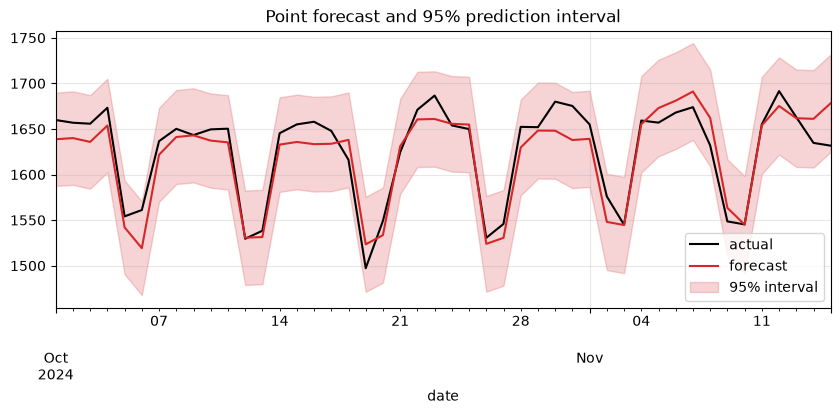

Share of actual values inside the 95% interval: 98.9%


In [4]:
train, actual = y[train_slice], y[test_slice]
model = fit_model(train, exog[train_slice])
fc = model.get_forecast(len(actual), exog=exog[test_slice])
mean, ci = fc.predicted_mean, fc.conf_int(alpha=0.05)

fig, ax = plt.subplots()
actual["2024-10-01":"2024-11-15"].plot(ax=ax, color="black", label="actual")
mean["2024-10-01":"2024-11-15"].plot(ax=ax, color="tab:red", label="forecast")
ax.fill_between(ci["2024-10-01":"2024-11-15"].index, ci["2024-10-01":"2024-11-15"].iloc[:, 0],
                ci["2024-10-01":"2024-11-15"].iloc[:, 1], color="tab:red", alpha=0.2, label="95% interval")
ax.legend()
ax.set_title("Point forecast and 95% prediction interval")
plt.show()

inside = ((actual >= ci.iloc[:, 0]) & (actual <= ci.iloc[:, 1])).mean()
print(f"Share of actual values inside the 95% interval: {100 * inside:.1f}%")

A well-calibrated 95% interval covers about 95% of actual values. Much more than 95% means the interval is too wide, and much less means it is too narrow. Here the intervals are on the wide side, because the six outliers in the training data inflated the error variance. We deal with outliers in section 5.

## 2. Out-of-sample metrics

| Metric | Formula | Use |
| --- | --- | --- |
| MAE | $\frac{1}{n}\sum \lvert e_t \rvert$ | Same unit as the data. Easy to explain. |
| RMSE | $\sqrt{\frac{1}{n}\sum e_t^2}$ | Punishes large errors. |
| MAPE | $\frac{100}{n}\sum \lvert e_t / y_t \rvert$ | Percent. Breaks when $y_t$ is near zero. |
| MASE | MAE divided by the in-sample MAE of a seasonal naive forecast | Below 1 means better than the naive method. |

In [5]:
def metrics(actual, forecast, train, m=7):
    e = actual - forecast
    scale = (train - train.shift(m)).abs().mean()          # in-sample seasonal naive MAE
    return {"MAE": e.abs().mean(),
            "RMSE": np.sqrt((e ** 2).mean()),
            "MAPE %": 100 * (e / actual).abs().mean(),
            "MASE": e.abs().mean() / scale}


pd.Series(metrics(actual, mean, train)).round(2).to_frame("SARIMAX, 6-month horizon")

,"SARIMAX, 6-month horizon"
MAE,15.20
RMSE,18.74
MAPE %,0.94
MASE,0.54


## 3. Rolling-origin backtest

One train and test split gives one number, which can be lucky. A **rolling-origin backtest** repeats the forecast from many starting points (origins). At each origin, fit on the data so far, forecast the next 7 days, and move on. Two window strategies:

- **Expanding window:** use all data up to the origin.
- **Rolling window:** use only the last 730 days, which adapts faster after a change.

Always compare with a **baseline**. Here the baseline is the seasonal naive forecast: the value from the same weekday last week.

In [6]:
H, STEP, ROLL = 7, 14, 730
origins = pd.date_range("2024-01-01", "2024-12-24", freq=pd.offsets.Day(STEP))
start = pd.Timestamp("2021-01-01")

records = []
for origin in origins:
    hist_end = origin - pd.offsets.Day(1)
    horizon = pd.date_range(origin, periods=H, freq="D")
    truth = y.loc[horizon]
    for strategy, begin in [("expanding", start), ("rolling 730d", max(start, hist_end - pd.offsets.Day(ROLL - 1)))]:
        m = fit_model(y.loc[begin:hist_end], exog.loc[begin:hist_end])
        f = m.get_forecast(H, exog=exog.loc[horizon]).predicted_mean
        records.append(pd.DataFrame({"origin": origin, "step": range(1, H + 1), "strategy": strategy,
                                     "error": truth.values - f.values, "truth": truth.values}))
    naive = y.shift(7).loc[horizon]                       # same weekday last week
    records.append(pd.DataFrame({"origin": origin, "step": range(1, H + 1), "strategy": "seasonal naive",
                                 "error": truth.values - naive.values, "truth": truth.values}))
bt = pd.concat(records, ignore_index=True)
print("origins:", len(origins), "| forecasts:", len(bt))

origins: 26 | forecasts: 546


,MAE,RMSE,MAPE %,MASE
strategy,,,,
expanding,12.93,16.50,0.80,0.47
rolling 730d,13.21,16.96,0.82,0.48
seasonal naive,26.42,35.85,1.63,0.95


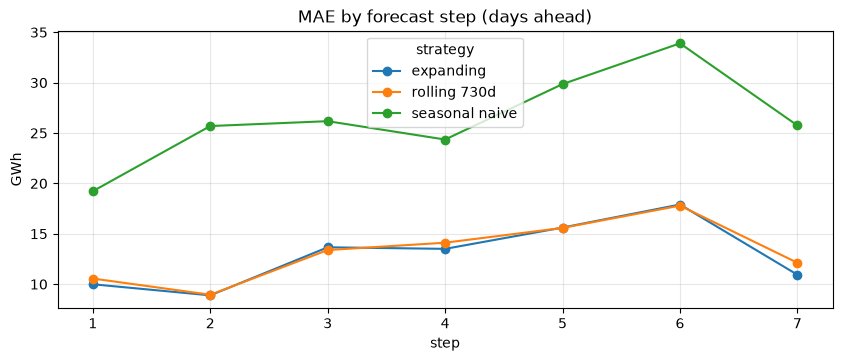

In [7]:
scale = (y[:"2023-12-31"] - y[:"2023-12-31"].shift(7)).abs().mean()
summary = bt.groupby("strategy").apply(lambda g: pd.Series({
    "MAE": g.error.abs().mean(),
    "RMSE": np.sqrt((g.error ** 2).mean()),
    "MAPE %": 100 * (g.error / g.truth).abs().mean(),
    "MASE": g.error.abs().mean() / scale,
}), include_groups=False).round(2)
display(summary)

by_step = bt.pivot_table(index="step", columns="strategy", values="error", aggfunc=lambda e: e.abs().mean())
by_step.plot(marker="o", title="MAE by forecast step (days ahead)")
plt.ylabel("GWh")
plt.show()

**Read the result.** A model earns its place only if it beats the baseline in the same backtest. MASE below 1 means the model beats the in-sample seasonal naive method. Look at the error by step: errors usually grow with the horizon.

## 4. Structural breaks

The data has a demand shock that starts on 2020-03-15 and fades over about four months. A model fitted before the shock cannot know about it. The next cell fits on data up to 2020-03-10 and forecasts the following 120 days.

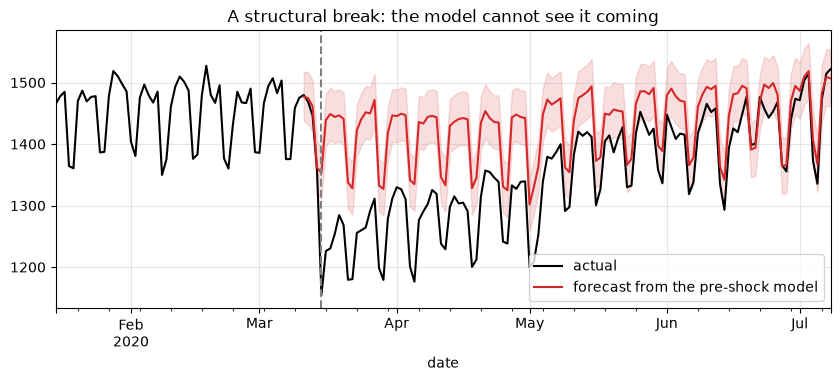

MAE during the shock = 81.1 GWh


In [8]:
pre = slice("2015-01-01", "2020-03-10")
post = slice("2020-03-11", "2020-07-08")
m_pre = fit_model(y[pre], exog[pre])
f_pre = m_pre.get_forecast(len(y[post]), exog=exog[post])
mean_pre, ci_pre = f_pre.predicted_mean, f_pre.conf_int()

fig, ax = plt.subplots()
y["2020-01-15":"2020-07-08"].plot(ax=ax, color="black", label="actual")
mean_pre.plot(ax=ax, color="tab:red", label="forecast from the pre-shock model")
ax.fill_between(ci_pre.index, ci_pre.iloc[:, 0], ci_pre.iloc[:, 1], color="tab:red", alpha=0.15)
ax.axvline(pd.Timestamp("2020-03-15"), color="gray", ls="--")
ax.legend()
ax.set_title("A structural break: the model cannot see it coming")
plt.show()
print(f"MAE during the shock = {(y[post] - mean_pre).abs().mean():.1f} GWh")

You cannot forecast a break you have never seen. You can handle it in four ways:

1. **Detect and report it.** State the date and the cause in your methods section.
2. **Model it with an intervention variable** if you know its shape.
3. **Use a shorter or rolling window** so the model forgets the old regime.
4. **Use wider intervals or scenario forecasts** when you expect another break.

The next cell uses option 2. It adds a regressor that jumps on the break date and decays, and refits on the full history.

In [9]:
k = np.arange(len(y))
s0 = y.index.get_loc(pd.Timestamp("2020-03-15"))
shock = pd.Series(np.where((k >= s0) & (k < s0 + 120), np.exp(-(k - s0) / 55.0), 0.0), index=y.index, name="shock")
exog_s = exog.assign(shock=shock)

full = slice("2015-01-01", "2024-06-30")
m_plain = fit_model(y[full], exog[full])
m_shock = fit_model(y[full], exog_s[full])
print(f"AIC without the intervention variable = {m_plain.aic:.0f}")
print(f"AIC with the intervention variable    = {m_shock.aic:.0f}")
print(f"estimated shock effect on the first day = {m_shock.params['shock']:.0f} GWh")

AIC without the intervention variable = 31163
AIC with the intervention variable    = 30880
estimated shock effect on the first day = -196 GWh


## 5. Outliers

A few extreme points inflate the error variance and widen the intervals. Find them with standardized residuals. The first few residuals are not reliable because the model starts up, so skip the first 8.

Flagged dates (|z| > 4):


,date,z-score
0,2016-02-12,18.6
1,2016-02-13,-6.6
2,2017-05-25,17.2
3,2017-05-26,-6.9
4,2019-07-31,12.5
5,2019-08-01,-4.7
6,2021-05-23,-17.6
7,2021-05-24,4.9
8,2023-03-13,15.7
9,2023-03-14,-5.2


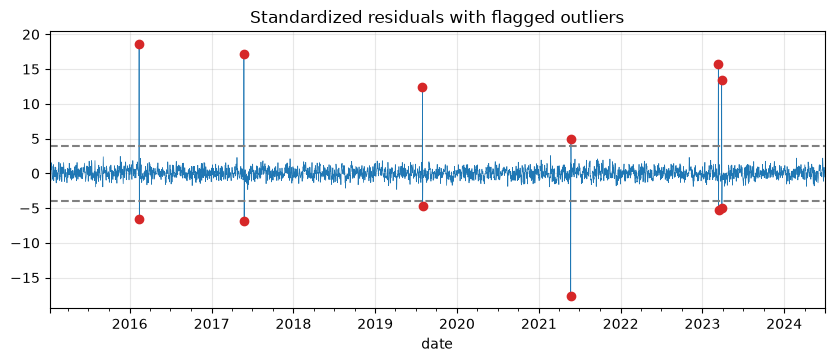

In [10]:
resid = m_shock.resid.iloc[8:]
z = resid / resid.std()
flagged = z[z.abs() > 4]
print("Flagged dates (|z| > 4):")
display(pd.DataFrame({"date": flagged.index.strftime("%Y-%m-%d"), "z-score": flagged.round(1).values}))

fig, ax = plt.subplots()
z.plot(ax=ax, lw=0.5)
ax.scatter(flagged.index, flagged, color="tab:red", zorder=3)
ax.axhline(4, color="gray", ls="--")
ax.axhline(-4, color="gray", ls="--")
ax.set_title("Standardized residuals with flagged outliers")
plt.show()

The generator added six outliers. The cell flags twelve dates: six large spikes (|z| above 12) and six smaller echoes of opposite sign on the next day. The echo is a normal side effect of the moving average term, because the model tries to correct itself after a shock. Count the spikes, not the echoes. Real data is never this clean. After you flag a point, **find out why** (a meter error, an event, a typo). Then pick one action and report it: keep it, replace it with a missing value, or add a dummy variable for that date. Never delete points silently.

## 6. A small forecast pipeline

A forecast that runs once is a notebook. A forecast that runs every week is a pipeline. The minimum pipeline does four things: **validate** the input, **fit**, **forecast**, and **record** the result with the metadata needed to audit it later.

In [11]:
import json


def run_forecast(history, x_history, x_future, horizon, out_dir=None):
    """Validate the input, fit the model, forecast, and optionally save the result."""
    # 1. Validate. Fail loudly instead of forecasting from bad data.
    if history.index.freq is None or history.index.freqstr != "D":
        raise ValueError("history must have a daily index")
    if history.isna().any():
        raise ValueError("history has missing values")
    if len(history) < 365:
        raise ValueError("history is shorter than one year")
    if len(x_future) != horizon:
        raise ValueError("future regressors must cover the whole horizon")

    # 2. Fit and 3. forecast.
    model = fit_model(history, x_history)
    fc = model.get_forecast(horizon, exog=x_future)
    out = pd.concat([fc.predicted_mean.rename("forecast"), fc.conf_int(alpha=0.05)], axis=1)
    out.columns = ["forecast", "lower_95", "upper_95"]

    # 4. Record the result and the metadata.
    meta = {"fitted_on": [str(history.index.min().date()), str(history.index.max().date())],
            "order": ORDER, "seasonal_order": SEASONAL, "aic": round(float(model.aic), 1),
            "horizon": horizon, "n_obs": int(len(history))}
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out.to_csv(out_dir / "forecast.csv")
        (out_dir / "metadata.json").write_text(json.dumps(meta, indent=2))
    return out, meta


result, meta = run_forecast(y[train_slice], exog[train_slice], exog[test_slice].iloc[:14], 14, out_dir="outputs")
display(result.head(3).round(1))
print(json.dumps(meta, indent=2))

,forecast,lower_95,upper_95
2024-07-01,1647.6,1603.5,1691.7
2024-07-02,1676.9,1630.5,1723.4
2024-07-03,1668.8,1622.0,1715.6


{
  "fitted_on": [
    "2021-01-01",
    "2024-06-30"
  ],
  "order": [
    2,
    0,
    1
  ],
  "seasonal_order": [
    0,
    1,
    1,
    7
  ],
  "aic": 11567.7,
  "horizon": 14,
  "n_obs": 1277
}


**Before you deploy**

- **Schedule:** refit on a fixed schedule, for example weekly.
- **Monitor:** compare each new actual value with its forecast. Alert when the recent MAE passes a threshold, for example 1.5 times the backtest MAE.
- **Version:** save the data range, the orders, and the package versions with every forecast.
- **Fallback:** keep the seasonal naive forecast as a safe default if the model fails validation.
- **Inputs:** if the model needs regressors, you need a reliable source for their future values.

## Take-home

- Report intervals next to point forecasts, and check their coverage.
- Backtest from many origins and always beat a baseline.
- Name your breaks and outliers. Do not hide them.
- A forecast is a process, not a number.

**Next:** open notebook 06 and try the whole workflow on your own data.